<a href="https://colab.research.google.com/github/Ryuta-Y/cv-practice/blob/main/vit_cifar10_finetune.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import importlib.util
import json
import os
import random
import subprocess
import sys
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch


def in_colab() -> bool:
    try:
        import google.colab

        return True
    except ImportError:
        return False


def ensure_packages(packages: dict[str, str]) -> None:

    missing = [spec for mod, spec in packages.items() if importlib.util.find_spec(mod) is None]
    if not missing:
        return

    print("不足パッケージをインストールします:")
    for pkg in missing:
        print(" -", pkg)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])


def seed_everything(seed: int = 42) -> None:
    """乱数シード固定"""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def get_device() -> torch.device:
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")


def print_runtime_info() -> None:
    device = get_device()
    print(f"実行デバイス: {device}")
    if device.type == "cuda":
        print("GPU 名:", torch.cuda.get_device_name(0))
        print("CUDA version:", torch.version.cuda)


def get_output_dir(name: str, prefer_drive: bool = False) -> Path:
    if prefer_drive and in_colab() and Path("/content/drive/MyDrive").exists():
        root = Path("/content/drive/MyDrive/learning_guide_outputs")
    else:
        root = Path("/content/learning_guide_outputs") if in_colab() else Path("learning_guide_outputs")
    output_dir = root / name
    output_dir.mkdir(parents=True, exist_ok=True)
    print(f"出力先ディレクトリ: {output_dir}")
    return output_dir


def download_file(url: str, output_path: Path) -> Path:
    output_path.parent.mkdir(parents=True, exist_ok=True)
    if output_path.exists():
        print(f"既に存在するため再利用します: {output_path}")
        return output_path

    print(f"ダウンロード中: {url}")
    urllib.request.urlretrieve(url, output_path)
    return output_path


def maybe_mount_drive(do_mount: bool = False) -> None:
    if not do_mount or not in_colab():
        return

    from google.colab import drive  # type: ignore

    drive.mount("/content/drive")


def maybe_upload_files() -> list[Path]:
    if not in_colab():
        return []

    from google.colab import files  # type: ignore

    uploaded = files.upload()
    return [Path(name) for name in uploaded.keys()]


def show_image_grid(
    images: list[np.ndarray],
    titles: list[str] | None = None,
    cols: int = 4,
    figsize=(14, 8),
    output_path: Path | None = None,
) -> None:
    """画像を格子状に並べて表示し、必要なら画像ファイルとして保存する。"""
    if not images:
        return

    rows = int(np.ceil(len(images) / cols))
    plt.figure(figsize=figsize)
    for index, image in enumerate(images, start=1):
        plt.subplot(rows, cols, index)
        plt.imshow(image)
        plt.axis("off")
        if titles and index - 1 < len(titles):
            plt.title(titles[index - 1], fontsize=10)
    plt.tight_layout()
    if output_path is not None:
        output_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(output_path, dpi=200, bbox_inches="tight")
        print(f"画像グリッドを保存しました: {output_path}")
    plt.show()


def plot_training_curves(
    train_losses: list[float],
    val_losses: list[float],
    train_accs: list[float],
    val_accs: list[float],
    output_path: Path | None = None,
) -> None:
    """学習曲線を 2 枚並べて表示・保存する。"""
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label="train loss")
    plt.plot(val_losses, label="val loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title("Loss Curve")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(train_accs, label="train acc")
    plt.plot(val_accs, label="val acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title("Accuracy Curve")
    plt.legend()

    plt.tight_layout()
    if output_path is not None:
        plt.savefig(output_path, dpi=200, bbox_inches="tight")
        print(f"学習曲線を保存しました: {output_path}")
    plt.show()


def plot_grouped_bar(
    labels: list[str],
    series: dict[str, list[float]],
    title: str,
    ylabel: str,
    output_path: Path | None = None,
) -> None:
    """複数手法の比較を棒グラフで表示する。"""
    if not labels or not series:
        return

    x = np.arange(len(labels))
    width = 0.8 / max(len(series), 1)

    plt.figure(figsize=(max(8, 1.8 * len(labels)), 5))
    for index, (name, values) in enumerate(series.items()):
        offset = (index - (len(series) - 1) / 2) * width
        plt.bar(x + offset, values, width=width, label=name)

    plt.xticks(x, labels, rotation=15)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    if output_path is not None:
        plt.savefig(output_path, dpi=200, bbox_inches="tight")
        print(f"比較グラフを保存しました: {output_path}")
    plt.show()


def denormalize_image(image_tensor: torch.Tensor, mean: tuple[float, ...], std: tuple[float, ...]) -> np.ndarray:
    """正規化済みテンソルを可視化しやすい画像へ戻す。"""
    image = image_tensor.detach().cpu().clone()
    for channel, m, s in zip(image, mean, std):
        channel.mul_(s).add_(m)
    image = image.clamp(0, 1)
    return image.permute(1, 2, 0).numpy()


def save_text(text: str, output_path: Path) -> None:
    """メモや結果要約を保存する。"""
    output_path.parent.mkdir(parents=True, exist_ok=True)
    output_path.write_text(text, encoding="utf-8")
    print(f"テキストを保存しました: {output_path}")


def save_json(data: dict, output_path: Path) -> None:
    """実験設定や評価指標を JSON で保存する。"""
    output_path.parent.mkdir(parents=True, exist_ok=True)
    output_path.write_text(json.dumps(data, ensure_ascii=False, indent=2), encoding="utf-8")
    print(f"JSON を保存しました: {output_path}")


def count_parameters(model: torch.nn.Module, trainable_only: bool = False) -> int:
    """モデルのパラメータ数を数える。"""
    if trainable_only:
        return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)
    return sum(parameter.numel() for parameter in model.parameters())


def format_seconds(seconds: float) -> str:
    minutes, sec = divmod(seconds, 60)
    hours, minutes = divmod(minutes, 60)
    if hours >= 1:
        return f"{int(hours)}h {int(minutes)}m {sec:.1f}s"
    if minutes >= 1:
        return f"{int(minutes)}m {sec:.1f}s"
    return f"{seconds:.2f}s"


def sample_video_frames(video_path: Path, num_frames: int, stride: int = 1) -> list[np.ndarray]:
    import cv2

    cap = cv2.VideoCapture(str(video_path))
    frames: list[np.ndarray] = []
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    cap.release()

    if not frames:
        raise RuntimeError(f"動画からフレームを読めませんでした: {video_path}")

    candidate_frames = frames[:: max(1, stride)]
    if len(candidate_frames) == 1:
        return [candidate_frames[0].copy() for _ in range(num_frames)]

    indices = np.linspace(0, len(candidate_frames) - 1, num=num_frames, dtype=int)
    sampled = [candidate_frames[index].copy() for index in indices]
    while len(sampled) < num_frames:
        sampled.append(sampled[-1].copy())
    return sampled


Mounted at /content/drive
出力先ディレクトリ: /content/drive/MyDrive/learning_guide_outputs/02_vit_cifar10
実行デバイス: cuda
GPU 名: NVIDIA H100 80GB HBM3
CUDA version: 12.8


100%|██████████| 170M/170M [00:14<00:00, 11.6MB/s]


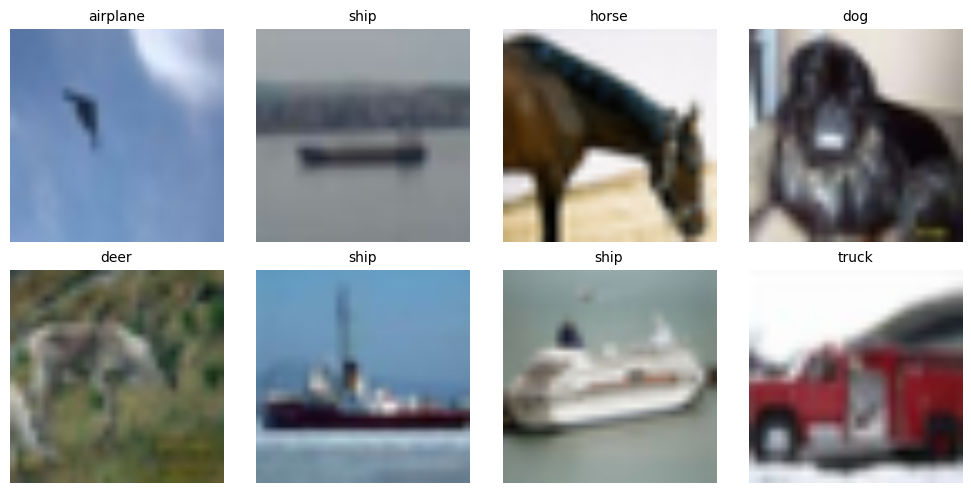

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 311MB/s]


resnet18_transfer_e8 parameters: total=11,181,642, trainable=5,130
[resnet18_transfer_e8][Epoch 1/8] train_loss=1.4820 train_acc=0.5580 val_loss=1.0116 val_acc=0.7226 epoch_time=15.09s
[resnet18_transfer_e8][Epoch 2/8] train_loss=0.8956 train_acc=0.7380 val_loss=0.7992 val_acc=0.7588 epoch_time=14.07s
[resnet18_transfer_e8][Epoch 3/8] train_loss=0.7652 train_acc=0.7611 val_loss=0.7121 val_acc=0.7778 epoch_time=14.25s
[resnet18_transfer_e8][Epoch 4/8] train_loss=0.7043 train_acc=0.7724 val_loss=0.6840 val_acc=0.7748 epoch_time=13.95s
[resnet18_transfer_e8][Epoch 5/8] train_loss=0.6613 train_acc=0.7849 val_loss=0.6445 val_acc=0.7860 epoch_time=13.86s
[resnet18_transfer_e8][Epoch 6/8] train_loss=0.6410 train_acc=0.7871 val_loss=0.6262 val_acc=0.7916 epoch_time=14.04s
[resnet18_transfer_e8][Epoch 7/8] train_loss=0.6259 train_acc=0.7914 val_loss=0.6189 val_acc=0.7928 epoch_time=14.24s
[resnet18_transfer_e8][Epoch 8/8] train_loss=0.6135 train_acc=0.7949 val_loss=0.6168 val_acc=0.7882 epoch_t

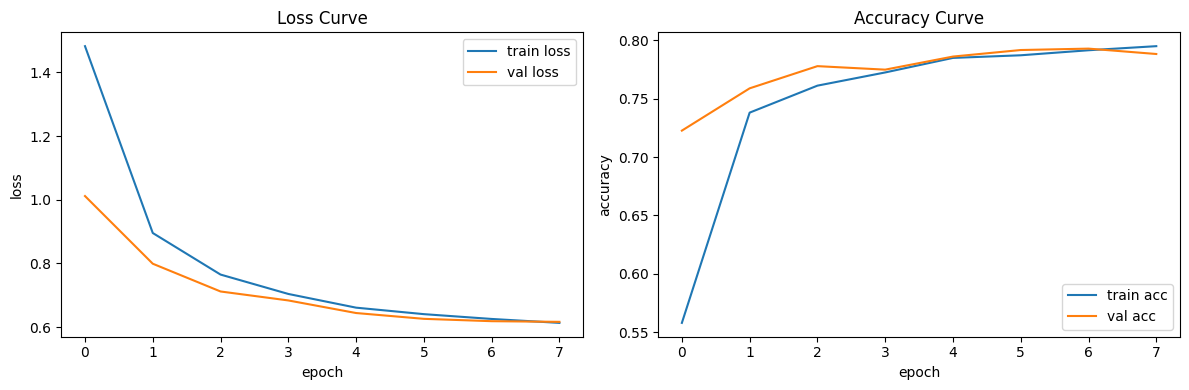

resnet18_transfer_e8 の最終 test loss: 0.6230
resnet18_transfer_e8 の最終 test accuracy: 0.7891
resnet18_transfer_e8 の test 評価時間: 5.47s
重みを保存しました: /content/drive/MyDrive/learning_guide_outputs/02_vit_cifar10/resnet18_transfer_e8.pt
resnet18_transfer_e16 parameters: total=11,181,642, trainable=5,130
[resnet18_transfer_e16][Epoch 1/16] train_loss=1.5035 train_acc=0.5482 val_loss=1.0205 val_acc=0.7240 epoch_time=13.69s
[resnet18_transfer_e16][Epoch 2/16] train_loss=0.9057 train_acc=0.7350 val_loss=0.8003 val_acc=0.7532 epoch_time=13.77s
[resnet18_transfer_e16][Epoch 3/16] train_loss=0.7668 train_acc=0.7632 val_loss=0.7241 val_acc=0.7688 epoch_time=13.91s
[resnet18_transfer_e16][Epoch 4/16] train_loss=0.7032 train_acc=0.7756 val_loss=0.6726 val_acc=0.7800 epoch_time=13.84s
[resnet18_transfer_e16][Epoch 5/16] train_loss=0.6704 train_acc=0.7769 val_loss=0.6360 val_acc=0.7928 epoch_time=13.65s
[resnet18_transfer_e16][Epoch 6/16] train_loss=0.6447 train_acc=0.7870 val_loss=0.6309 val_acc=0.7882 epoc

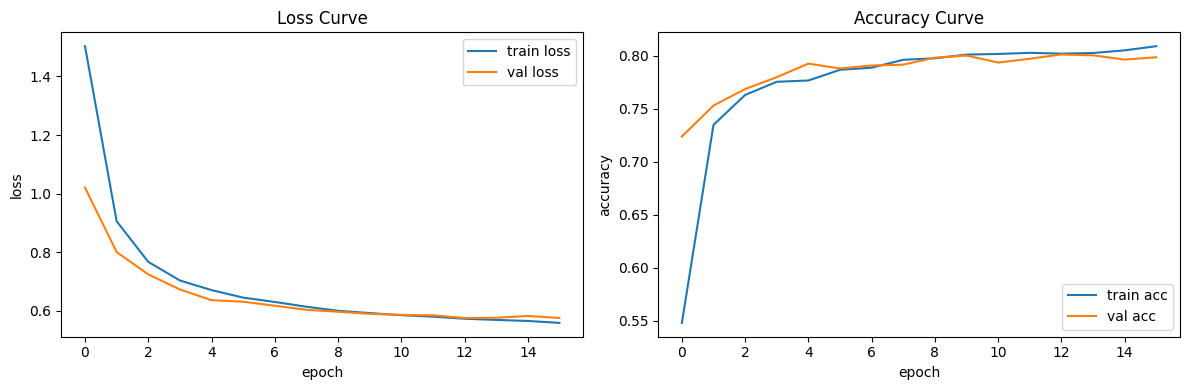

resnet18_transfer_e16 の最終 test loss: 0.5907
resnet18_transfer_e16 の最終 test accuracy: 0.7979
resnet18_transfer_e16 の test 評価時間: 5.52s
重みを保存しました: /content/drive/MyDrive/learning_guide_outputs/02_vit_cifar10/resnet18_transfer_e16.pt
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 287MB/s]


vit_b16_transfer_e8 parameters: total=85,806,346, trainable=7,690
[vit_b16_transfer_e8][Epoch 1/8] train_loss=0.6113 train_acc=0.8708 val_loss=0.2663 val_acc=0.9302 epoch_time=14.11s
[vit_b16_transfer_e8][Epoch 2/8] train_loss=0.2337 train_acc=0.9339 val_loss=0.2029 val_acc=0.9398 epoch_time=14.10s
[vit_b16_transfer_e8][Epoch 3/8] train_loss=0.1920 train_acc=0.9429 val_loss=0.1803 val_acc=0.9452 epoch_time=14.16s
[vit_b16_transfer_e8][Epoch 4/8] train_loss=0.1708 train_acc=0.9464 val_loss=0.1686 val_acc=0.9472 epoch_time=14.00s
[vit_b16_transfer_e8][Epoch 5/8] train_loss=0.1574 train_acc=0.9497 val_loss=0.1615 val_acc=0.9480 epoch_time=14.13s
[vit_b16_transfer_e8][Epoch 6/8] train_loss=0.1463 train_acc=0.9542 val_loss=0.1567 val_acc=0.9510 epoch_time=14.10s
[vit_b16_transfer_e8][Epoch 7/8] train_loss=0.1387 train_acc=0.9564 val_loss=0.1539 val_acc=0.9518 epoch_time=14.32s
[vit_b16_transfer_e8][Epoch 8/8] train_loss=0.1310 train_acc=0.9591 val_loss=0.1509 val_acc=0.9506 epoch_time=14.18

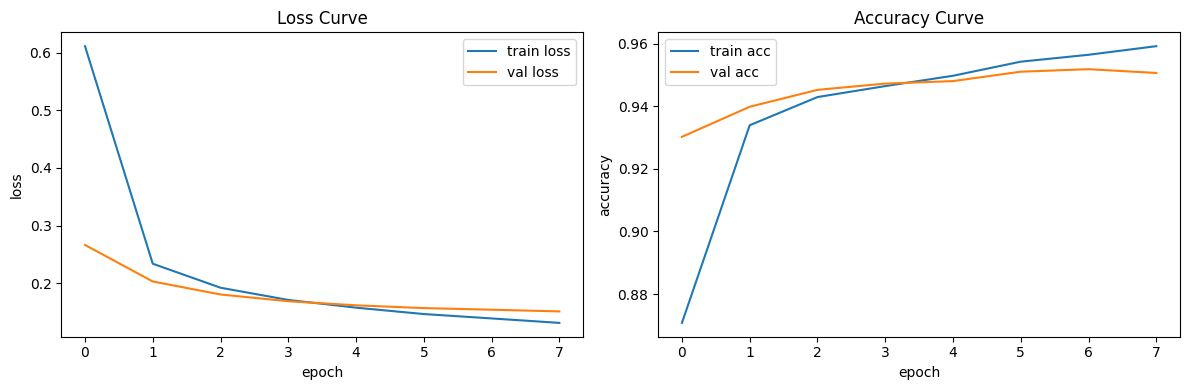

vit_b16_transfer_e8 の最終 test loss: 0.1595
vit_b16_transfer_e8 の最終 test accuracy: 0.9481
vit_b16_transfer_e8 の test 評価時間: 5.57s
重みを保存しました: /content/drive/MyDrive/learning_guide_outputs/02_vit_cifar10/vit_b16_transfer_e8.pt
vit_b16_transfer_e16 parameters: total=85,806,346, trainable=7,690
[vit_b16_transfer_e16][Epoch 1/16] train_loss=0.6259 train_acc=0.8646 val_loss=0.2681 val_acc=0.9306 epoch_time=14.12s
[vit_b16_transfer_e16][Epoch 2/16] train_loss=0.2351 train_acc=0.9338 val_loss=0.2067 val_acc=0.9372 epoch_time=13.89s
[vit_b16_transfer_e16][Epoch 3/16] train_loss=0.1921 train_acc=0.9419 val_loss=0.1834 val_acc=0.9422 epoch_time=14.03s
[vit_b16_transfer_e16][Epoch 4/16] train_loss=0.1712 train_acc=0.9472 val_loss=0.1717 val_acc=0.9460 epoch_time=14.04s
[vit_b16_transfer_e16][Epoch 5/16] train_loss=0.1576 train_acc=0.9507 val_loss=0.1627 val_acc=0.9490 epoch_time=13.89s
[vit_b16_transfer_e16][Epoch 6/16] train_loss=0.1465 train_acc=0.9542 val_loss=0.1576 val_acc=0.9486 epoch_time=13.7

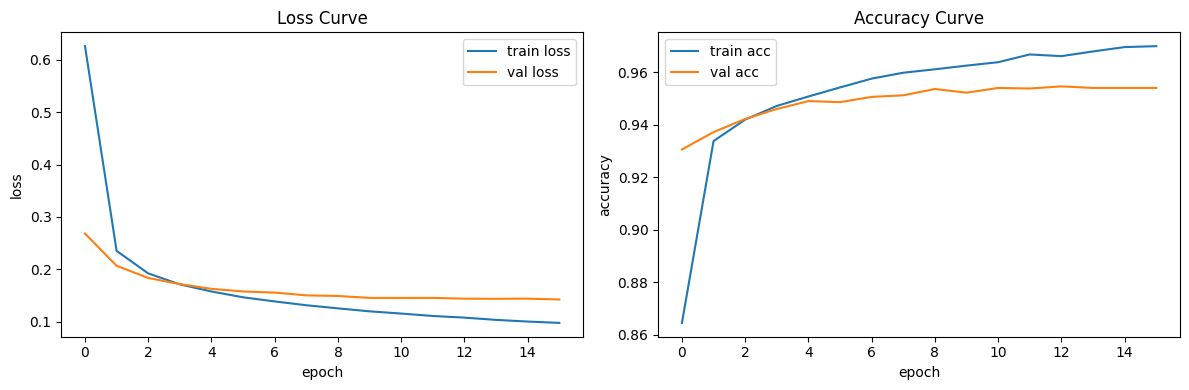

vit_b16_transfer_e16 の最終 test loss: 0.1491
vit_b16_transfer_e16 の最終 test accuracy: 0.9502
vit_b16_transfer_e16 の test 評価時間: 5.48s
重みを保存しました: /content/drive/MyDrive/learning_guide_outputs/02_vit_cifar10/vit_b16_transfer_e16.pt
比較グラフを保存しました: /content/drive/MyDrive/learning_guide_outputs/02_vit_cifar10/resnet_vs_vit_accuracy.png


/tmp/ipykernel_668/3743976968.py:182: UserWarning: Glyph 12514 (\N{KATAKANA LETTER MO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_668/3743976968.py:182: UserWarning: Glyph 12487 (\N{KATAKANA LETTER DE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_668/3743976968.py:182: UserWarning: Glyph 12523 (\N{KATAKANA LETTER RU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_668/3743976968.py:182: UserWarning: Glyph 31278 (\N{CJK UNIFIED IDEOGRAPH-7A2E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_668/3743976968.py:182: UserWarning: Glyph 21029 (\N{CJK UNIFIED IDEOGRAPH-5225}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_668/3743976968.py:182: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_668/3743976968.py:184: UserWarning: Glyph 12514 (\N{KATAKANA LETTER MO}) missing from font(s) DejaVu Sa

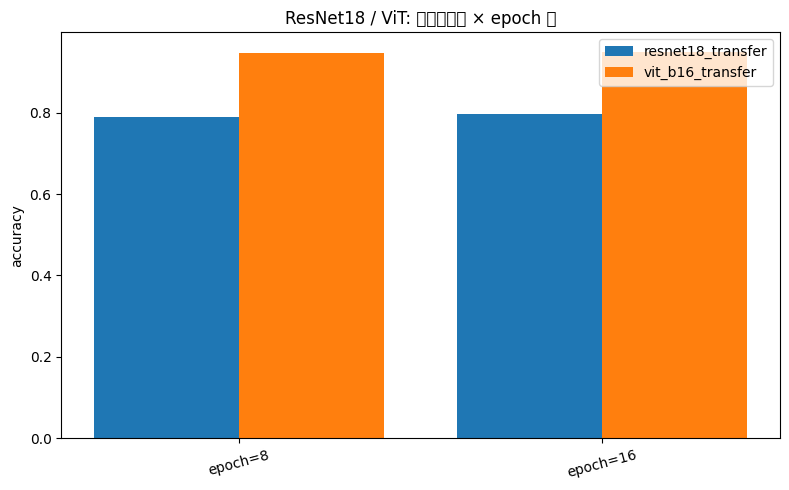

/tmp/ipykernel_668/3743976968.py:182: UserWarning: Glyph 26178 (\N{CJK UNIFIED IDEOGRAPH-6642}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_668/3743976968.py:182: UserWarning: Glyph 38291 (\N{CJK UNIFIED IDEOGRAPH-9593}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_668/3743976968.py:182: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_668/3743976968.py:182: UserWarning: Glyph 36611 (\N{CJK UNIFIED IDEOGRAPH-8F03}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_668/3743976968.py:184: UserWarning: Glyph 26178 (\N{CJK UNIFIED IDEOGRAPH-6642}) missing from font(s) DejaVu Sans.
  plt.savefig(output_path, dpi=200, bbox_inches="tight")
/tmp/ipykernel_668/3743976968.py:184: UserWarning: Glyph 38291 (\N{CJK UNIFIED IDEOGRAPH-9593}) missing from font(s) DejaVu Sans.
  plt.savefig(output_path, dpi=200, bbox_inches="tight")
/tmp/ipykernel_668/374

比較グラフを保存しました: /content/drive/MyDrive/learning_guide_outputs/02_vit_cifar10/resnet_vs_vit_runtime.png


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 26178 (\N{CJK UNIFIED IDEOGRAPH-6642}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 38291 (\N{CJK UNIFIED IDEOGRAPH-9593}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 27604 (\N{CJK UNIFIED IDEOGRAPH-6BD4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 36611 (\N{CJK UNIFIED IDEOGRAPH-8F03}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


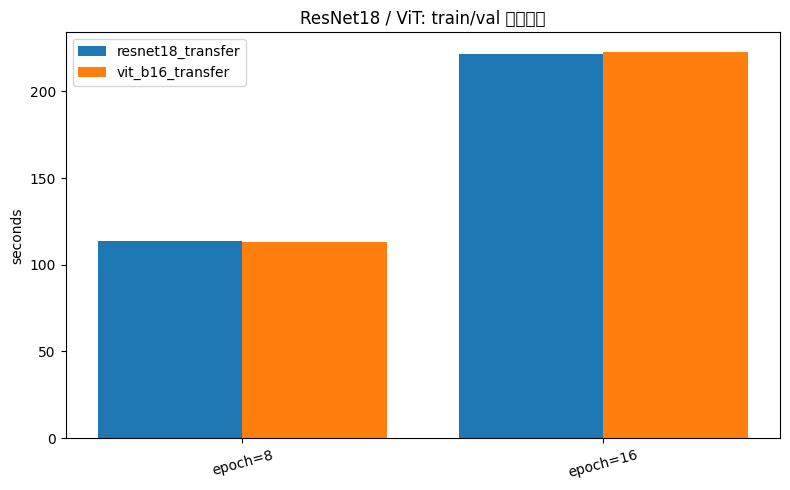

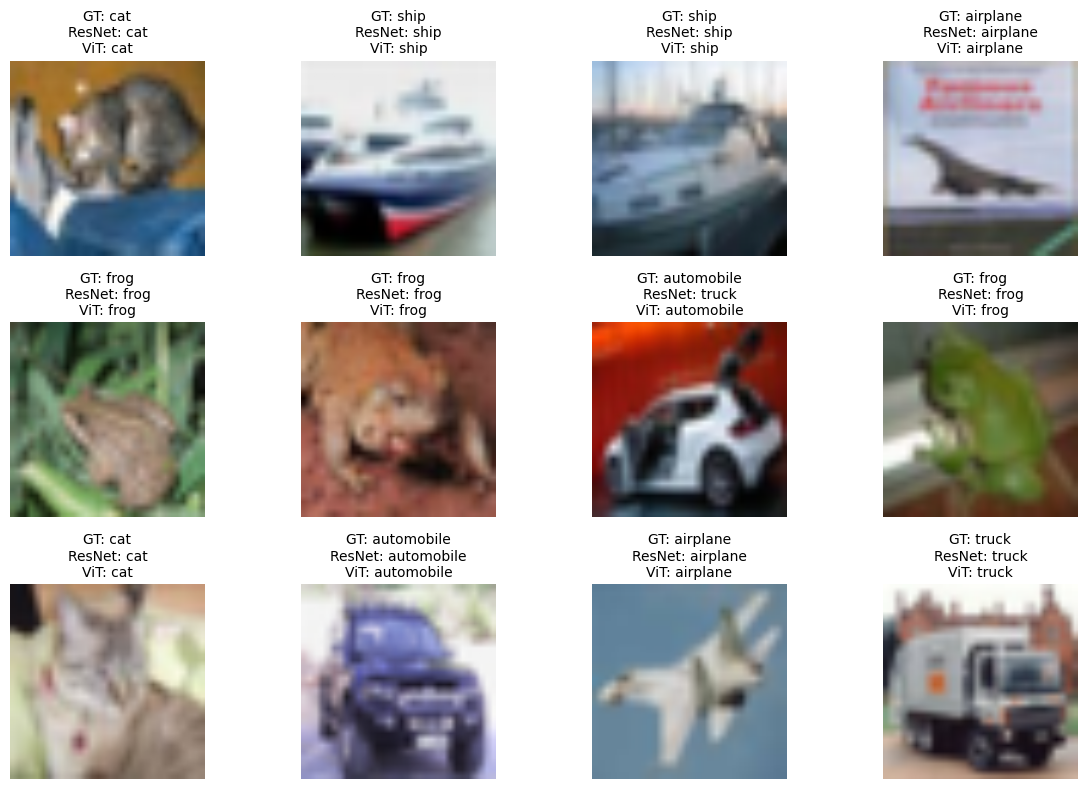

テキストを保存しました: /content/drive/MyDrive/learning_guide_outputs/02_vit_cifar10/summary.txt
JSON を保存しました: /content/drive/MyDrive/learning_guide_outputs/02_vit_cifar10/metrics.json


In [2]:
from __future__ import annotations

import sys
import time
from pathlib import Path

ensure_packages({})

import torch
from torch import nn
from torch.utils.data import DataLoader, Subset, random_split
from torchvision import datasets, models, transforms


SEED = 42
BATCH_SIZE = 64
EPOCHS = 16
EPOCH_OPTIONS = [8, 16]
LEARNING_RATE = 3e-4
TRAIN_SAMPLES = 20000
VAL_SAMPLES = 5000
NUM_WORKERS = 2
IMAGE_SIZE = 224
SAMPLE_GRID_COUNT = 8
SAMPLE_GRID_COLS = 4
PREDICTION_PREVIEW_COUNT = 12
PREDICTION_GRID_COLS = 4
SAMPLE_GRID_FIGSIZE = (10, 5)
PREDICTION_GRID_FIGSIZE = (12, 8)

MEAN = (0.4914, 0.4822, 0.4465)
STD = (0.2470, 0.2435, 0.2616)


def run_epoch(model, loader, criterion, optimizer, device):
    """1 epoch: train / eval."""
    is_train = optimizer is not None
    model.train(is_train)
    total_loss = 0.0
    total_correct = 0
    total_count = 0
    start_time = time.perf_counter()

    scaler = torch.amp.GradScaler("cuda") if is_train and device.type == "cuda" else None

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_train):
            with torch.amp.autocast(device_type=device.type, enabled=device.type == "cuda"):
                logits = model(images)
                loss = criterion(logits, labels)

            if is_train:
                if scaler is not None:
                    scaler.scale(loss).backward()
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    optimizer.step()

        preds = logits.argmax(dim=1)
        total_loss += loss.item() * labels.size(0)
        total_correct += (preds == labels).sum().item()
        total_count += labels.size(0)

    elapsed_sec = time.perf_counter() - start_time
    return total_loss / total_count, total_correct / total_count, elapsed_sec


def build_resnet18(num_classes: int = 10):
    """ResNet18 baseline."""
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    for param in model.parameters():
        param.requires_grad = False
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model


def build_vit_b16(num_classes: int = 10):
    """ViT head fine-tune."""
    model = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)
    for param in model.parameters():
        param.requires_grad = False
    model.heads.head = nn.Linear(model.heads.head.in_features, num_classes)
    return model


def train_model(model_name, model, train_loader, val_loader, test_loader, classes, test_dataset, device, output_dir, num_epochs):
    """1 model: train / eval / save."""
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW((param for param in model.parameters() if param.requires_grad), lr=LEARNING_RATE)
    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    epoch_times = []
    total_parameters = count_parameters(model)
    trainable_parameters = count_parameters(model, trainable_only=True)

    print(
        f"{model_name} parameters: total={total_parameters:,}, "
        f"trainable={trainable_parameters:,}"
    )

    for epoch in range(num_epochs):
        train_loss, train_acc, train_epoch_sec = run_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, val_epoch_sec = run_epoch(model, val_loader, criterion, optimizer=None, device=device)

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        epoch_times.append(
            {
                "epoch": epoch + 1,
                "train_seconds": train_epoch_sec,
                "val_seconds": val_epoch_sec,
                "total_seconds": train_epoch_sec + val_epoch_sec,
            }
        )

        print(
            f"[{model_name}][Epoch {epoch + 1}/{num_epochs}] "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
            f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} "
            f"epoch_time={format_seconds(train_epoch_sec + val_epoch_sec)}"
        )

    plot_training_curves(
        train_losses,
        val_losses,
        train_accs,
        val_accs,
        output_path=output_dir / f"{model_name}_training_curves.png",
    )

    # 評価: test は最後
    test_loss, test_acc, test_sec = run_epoch(model, test_loader, criterion, optimizer=None, device=device)
    print(f"{model_name} の最終 test loss: {test_loss:.4f}")
    print(f"{model_name} の最終 test accuracy: {test_acc:.4f}")
    print(f"{model_name} の test 評価時間: {format_seconds(test_sec)}")

    predictions = []
    model.eval()
    with torch.no_grad():
        for i in range(PREDICTION_PREVIEW_COUNT):
            image, label = test_dataset[i]
            logits = model(image.unsqueeze(0).to(device))
            pred = logits.argmax(dim=1).item()
            predictions.append((image, label, pred))

    torch.save(model.state_dict(), output_dir / f"{model_name}.pt")
    print(f"重みを保存しました: {output_dir / f'{model_name}.pt'}")

    return {
        "name": model_name,
        "num_epochs": num_epochs,
        "test_loss": test_loss,
        "test_acc": test_acc,
        "test_seconds": test_sec,
        "total_parameters": total_parameters,
        "trainable_parameters": trainable_parameters,
        "epoch_times": epoch_times,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_accs": train_accs,
        "val_accs": val_accs,
        "predictions": predictions,
    }


def main() -> None:
    overall_start = time.perf_counter()
    seed_everything(SEED)
    device = get_device()
    maybe_mount_drive(do_mount=True)
    output_dir = get_output_dir("02_vit_cifar10", prefer_drive=True)
    print_runtime_info()

    # 入力: 224x224
    train_transform = transforms.Compose(
        [
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize(MEAN, STD),
        ]
    )
    eval_transform = transforms.Compose(
        [
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.ToTensor(),
            transforms.Normalize(MEAN, STD),
        ]
    )

    train_dataset_full = datasets.CIFAR10(root=output_dir / "data", train=True, download=True, transform=train_transform)
    test_dataset = datasets.CIFAR10(root=output_dir / "data", train=False, download=True, transform=eval_transform)
    train_subset = Subset(train_dataset_full, list(range(TRAIN_SAMPLES + VAL_SAMPLES)))
    train_dataset, val_dataset = random_split(
        train_subset,
        [TRAIN_SAMPLES, VAL_SAMPLES],
        generator=torch.Generator().manual_seed(SEED),
    )

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    classes = train_dataset_full.classes
    sample_images = []
    sample_titles = []
    for i in range(SAMPLE_GRID_COUNT):
        image, label = train_dataset[i]
        sample_images.append(denormalize_image(image, MEAN, STD))
        sample_titles.append(classes[label])
    show_image_grid(sample_images, sample_titles, cols=SAMPLE_GRID_COLS, figsize=SAMPLE_GRID_FIGSIZE)

    results = []
    for num_epochs in EPOCH_OPTIONS:
        results.append(
            train_model(
                f"resnet18_transfer_e{num_epochs}",
                build_resnet18(num_classes=10).to(device),
                train_loader,
                val_loader,
                test_loader,
                classes,
                test_dataset,
                device,
                output_dir,
                num_epochs=num_epochs,
            )
        )
    for num_epochs in EPOCH_OPTIONS:
        results.append(
            train_model(
                f"vit_b16_transfer_e{num_epochs}",
                build_vit_b16(num_classes=10).to(device),
                train_loader,
                val_loader,
                test_loader,
                classes,
                test_dataset,
                device,
                output_dir,
                num_epochs=num_epochs,
            )
        )

    epoch_labels = [f"epoch={num_epochs}" for num_epochs in EPOCH_OPTIONS]
    plot_grouped_bar(
        labels=epoch_labels,
        series={
            "resnet18_transfer": [
                next(result["test_acc"] for result in results if result["name"] == f"resnet18_transfer_e{num_epochs}")
                for num_epochs in EPOCH_OPTIONS
            ],
            "vit_b16_transfer": [
                next(result["test_acc"] for result in results if result["name"] == f"vit_b16_transfer_e{num_epochs}")
                for num_epochs in EPOCH_OPTIONS
            ],
        },
        title="ResNet18 / ViT: モデル種別 × epoch 数",
        ylabel="accuracy",
        output_path=output_dir / "resnet_vs_vit_accuracy.png",
    )
    plot_grouped_bar(
        labels=epoch_labels,
        series={
            "resnet18_transfer": [
                sum(
                    item["total_seconds"]
                    for item in next(
                        result["epoch_times"] for result in results if result["name"] == f"resnet18_transfer_e{num_epochs}"
                    )
                )
                for num_epochs in EPOCH_OPTIONS
            ],
            "vit_b16_transfer": [
                sum(
                    item["total_seconds"]
                    for item in next(
                        result["epoch_times"] for result in results if result["name"] == f"vit_b16_transfer_e{num_epochs}"
                    )
                )
                for num_epochs in EPOCH_OPTIONS
            ],
        },
        title="ResNet18 / ViT: train/val 時間比較",
        ylabel="seconds",
        output_path=output_dir / "resnet_vs_vit_runtime.png",
    )

    preview_images = []
    preview_titles = []
    preview_results = [
        next(result for result in results if result["name"] == f"resnet18_transfer_e{max(EPOCH_OPTIONS)}"),
        next(result for result in results if result["name"] == f"vit_b16_transfer_e{max(EPOCH_OPTIONS)}"),
    ]
    for sample_index in range(PREDICTION_PREVIEW_COUNT):
        image = preview_results[0]["predictions"][sample_index][0]
        label = preview_results[0]["predictions"][sample_index][1]
        resnet_pred = preview_results[0]["predictions"][sample_index][2]
        vit_pred = preview_results[1]["predictions"][sample_index][2]
        preview_images.append(denormalize_image(image, MEAN, STD))
        # 比較: 同一画像
        preview_titles.append(
            f"GT: {classes[label]}\nResNet: {classes[resnet_pred]}\nViT: {classes[vit_pred]}"
        )
    show_image_grid(
        preview_images,
        preview_titles,
        cols=PREDICTION_GRID_COLS,
        figsize=PREDICTION_GRID_FIGSIZE,
    )
    overall_seconds = time.perf_counter() - overall_start
    summary_lines = [
        "ViT / ResNet 比較まとめ",
        f"EPOCH_OPTIONS: {EPOCH_OPTIONS}",
        f"Notebook total runtime: {format_seconds(overall_seconds)}",
    ]
    for result in results:
        summary_lines.extend(
            [
                f"{result['name']} test accuracy: {result['test_acc']:.4f}",
                f"{result['name']} best val accuracy: {max(result['val_accs']):.4f}",
                f"{result['name']} total train+val time: {format_seconds(sum(x['total_seconds'] for x in result['epoch_times']))}",
            ]
        )
    save_text("\n".join(summary_lines), output_dir / "summary.txt")
    save_json(
        {
            "config": {
                "seed": SEED,
                "batch_size": BATCH_SIZE,
                "epochs": EPOCHS,
                "epoch_options": EPOCH_OPTIONS,
                "learning_rate": LEARNING_RATE,
                "train_samples": TRAIN_SAMPLES,
                "val_samples": VAL_SAMPLES,
                "num_workers": NUM_WORKERS,
                "image_size": IMAGE_SIZE,
                "sample_grid_count": SAMPLE_GRID_COUNT,
                "sample_grid_cols": SAMPLE_GRID_COLS,
                "prediction_preview_count": PREDICTION_PREVIEW_COUNT,
                "prediction_grid_cols": PREDICTION_GRID_COLS,
            },
            "dataset": {
                "test_samples": len(test_dataset),
                "classes": classes,
            },
            "models": [
                {
                    "name": result["name"],
                    "test_loss": result["test_loss"],
                    "test_acc": result["test_acc"],
                    "test_seconds": result["test_seconds"],
                    "total_parameters": result["total_parameters"],
                    "trainable_parameters": result["trainable_parameters"],
                    "epoch_times": result["epoch_times"],
                    "best_val_acc": max(result["val_accs"]),
                    "final_train_acc": result["train_accs"][-1],
                    "final_val_acc": result["val_accs"][-1],
                }
                for result in results
            ],
            "runtime": {
                "overall_seconds": overall_seconds,
            },
        },
        output_dir / "metrics.json",
    )


main()


In [4]:
from pathlib import Path
from IPython.display import Image, Video, display, Markdown

out_dir = None
for candidate in [Path('/content/drive/MyDrive/learning_guide_outputs/02_vit_cifar10_finetune'), Path('/content/learning_guide_outputs/02_vit_cifar10_finetune')]:
    if candidate.exists():
        out_dir = candidate
        break

if out_dir is None:
    print('出力ディレクトリが見つかりませんでした。先に上の実験セルを実行してください。')
else:
    print(f'output_dir = {out_dir}')
    summary_path = out_dir / 'summary.txt'
    metrics_path = out_dir / 'metrics.json'
    if summary_path.exists():
        print('\n===== summary.txt =====\n')
        print(summary_path.read_text(encoding='utf-8'))
    if metrics_path.exists():
        print('\n===== metrics.json (先頭 1500 文字) =====\n')
        text = metrics_path.read_text(encoding='utf-8')
        print(text[:1500] + ('...' if len(text) > 1500 else ''))
    for png in sorted(out_dir.glob('*.png')):
        display(Markdown(f'### {png.name}'))
        display(Image(filename=str(png)))
    for mp4 in sorted(out_dir.glob('*.mp4')):
        display(Markdown(f'### {mp4.name}'))
        display(Video(str(mp4), embed=True, width=720))


出力ディレクトリが見つかりませんでした。先に上の実験セルを実行してください。
